# Introduction
Every beginner has done this dataset atleast once so as a self proclaimed beginner i'll try to perform EDA and predictive modelling for this dataset so lets see how this goes

# Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# i'll import other libraries along the way

# Loading dataset

In [2]:
df=pd.read_csv('/kaggle/input/iris-flower-dataset/IRIS.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


# Basic EDA

In [3]:
df.shape # to know structure of the dataset

(150, 5)

In [4]:
df.info() # to get basic info about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
df.describe() # to get statistical summary

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
df.isnull().sum() # to detect any null values

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

which means there are no null values in it

# Visualization 

## Pairplot

- A pairplot (Scatterplot Matrix) in Python's Seaborn library creates a grid of plots showing pairwise relationships between multiple numerical variables in a dataset, with scatterplots for each pair (off-diagonal) and univariate distributions (histograms or KDEs) for each variable on the diagonal, helping quickly spot correlations, patterns, and data distributions. 

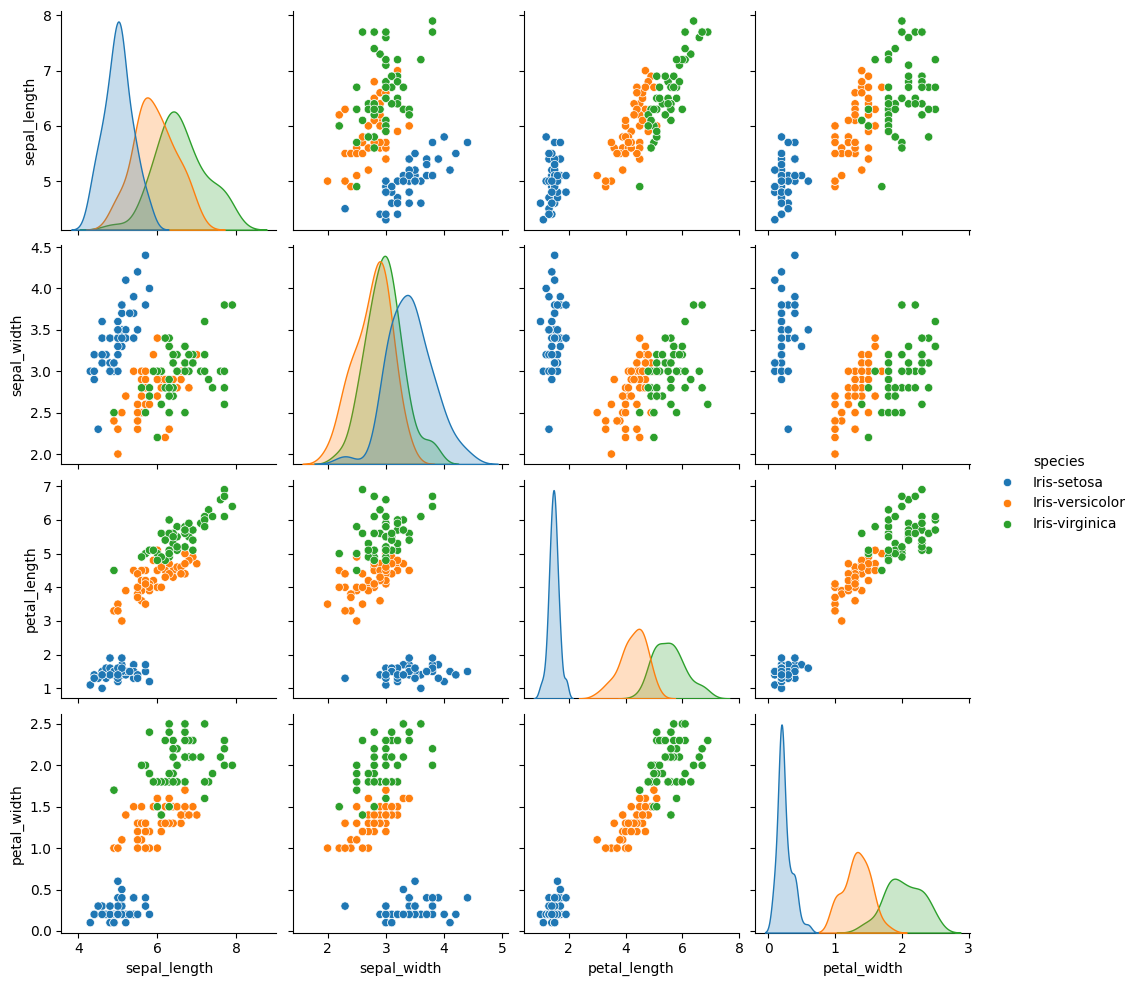

In [7]:
sns.pairplot(data=df,hue='species')
plt.show()

## Pair Plot Insights

The pairplot shows that petal length and petal width are the most discriminative features, clearly separating Iris-setosa from the other species. Iris-versicolor and Iris-virginica partially overlap but become more distinguishable using petal features, while sepal width contributes the least to class separation.


## Histogram of features

In [8]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

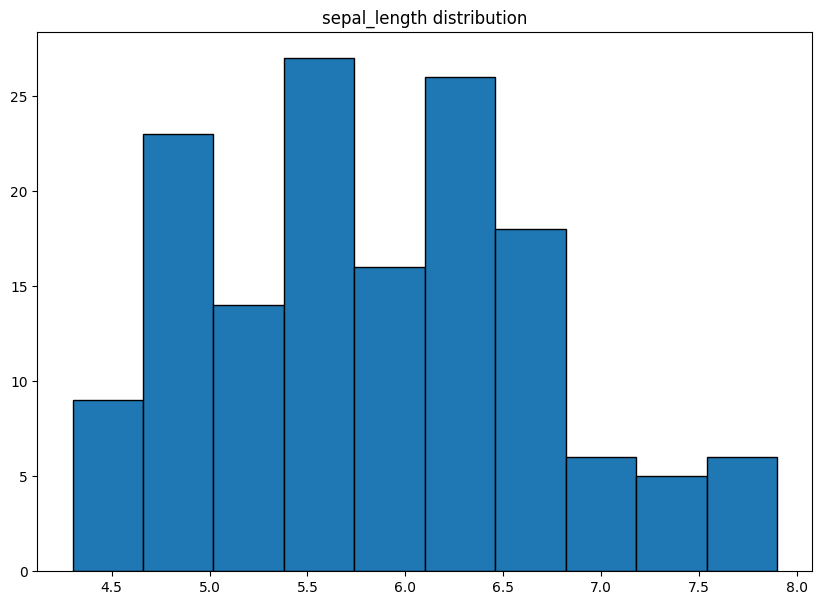

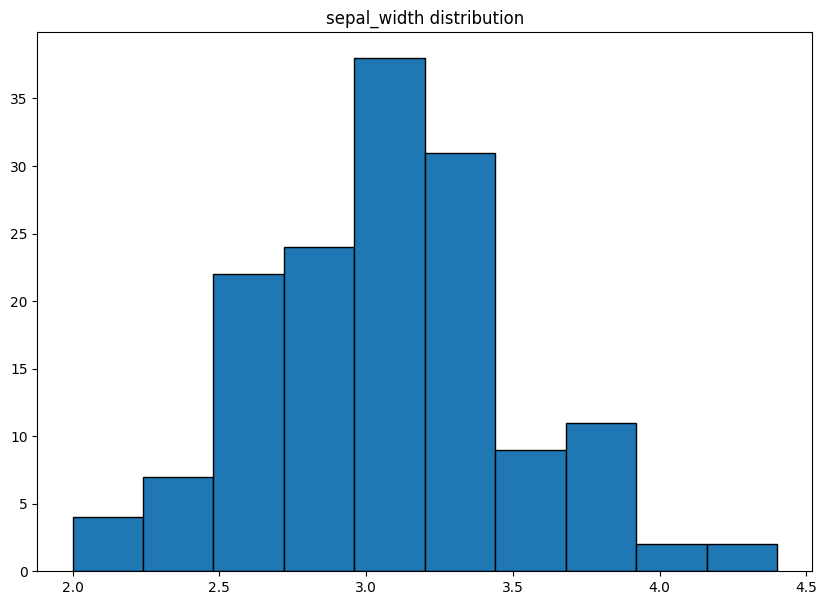

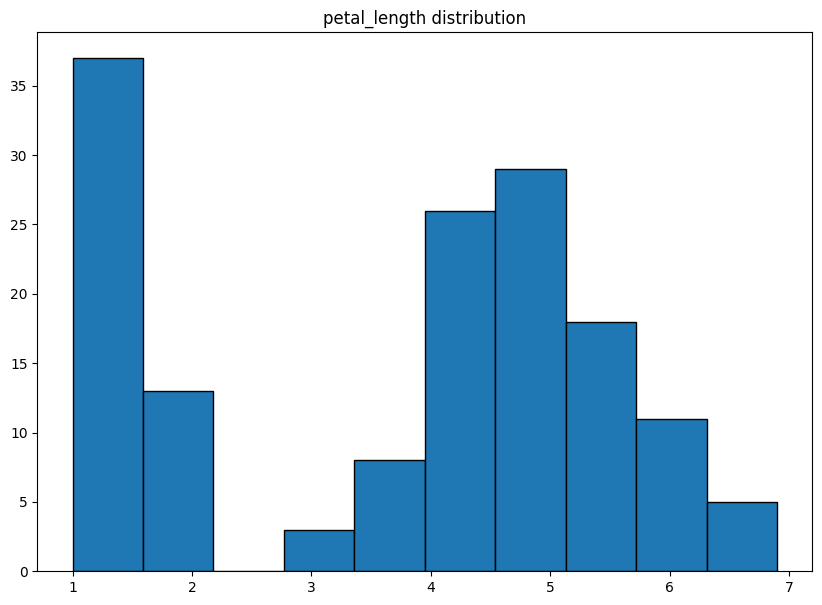

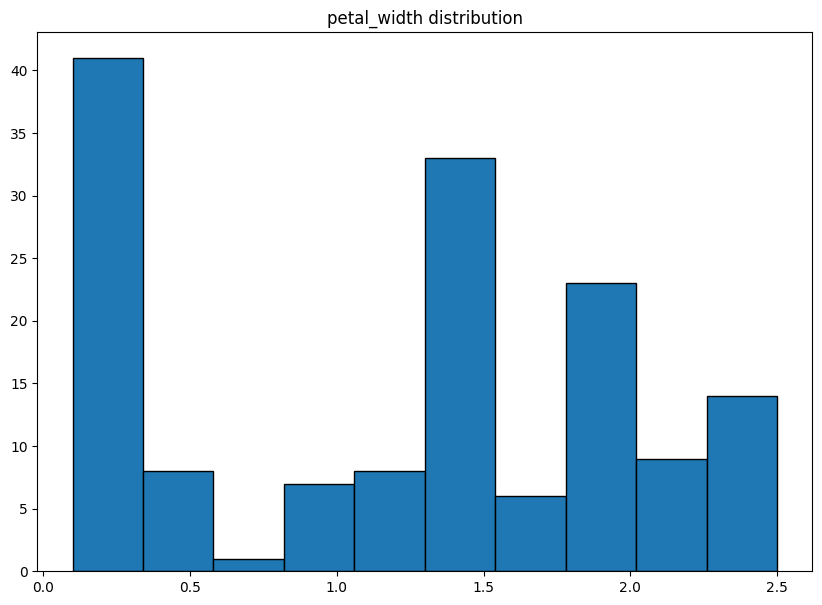

In [9]:
cols=df.select_dtypes(include=['float64'])
for i in cols:
    plt.figure(figsize=(10,7))
    plt.hist(df[i],edgecolor='black')
    plt.title(f"{i} distribution")
    plt.show()

## Histogram Insights

Sepal length and sepal width show overlapping, near-normal distributions, indicating limited power for species separation. In contrast, petal length and petal width exhibit clear multimodal patterns, reflecting strong differentiation between species. The sharp concentration of small petal values corresponds to Iris-setosa, while larger values represent versicolor and virginica, making petal features highly predictive for modeling.

## Boxplot of feature

Grouped By Species to get better insights

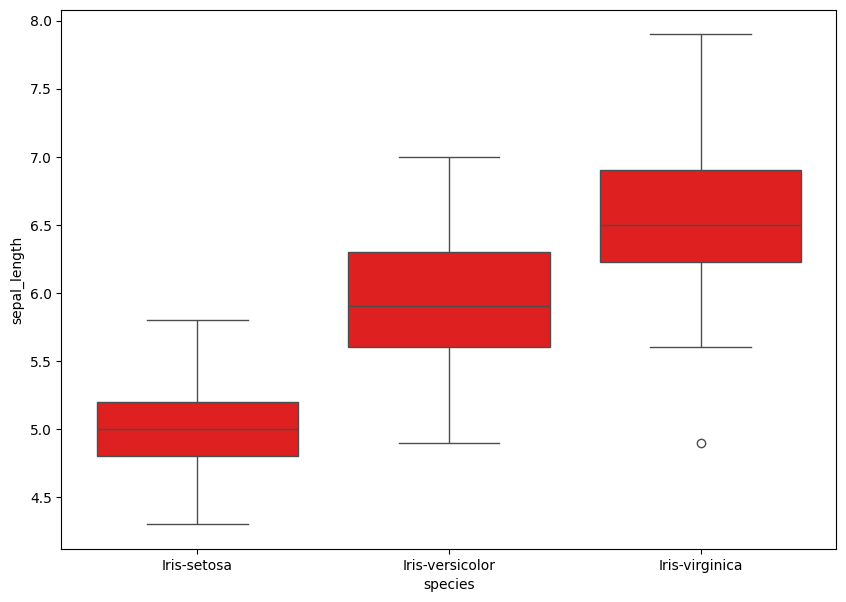

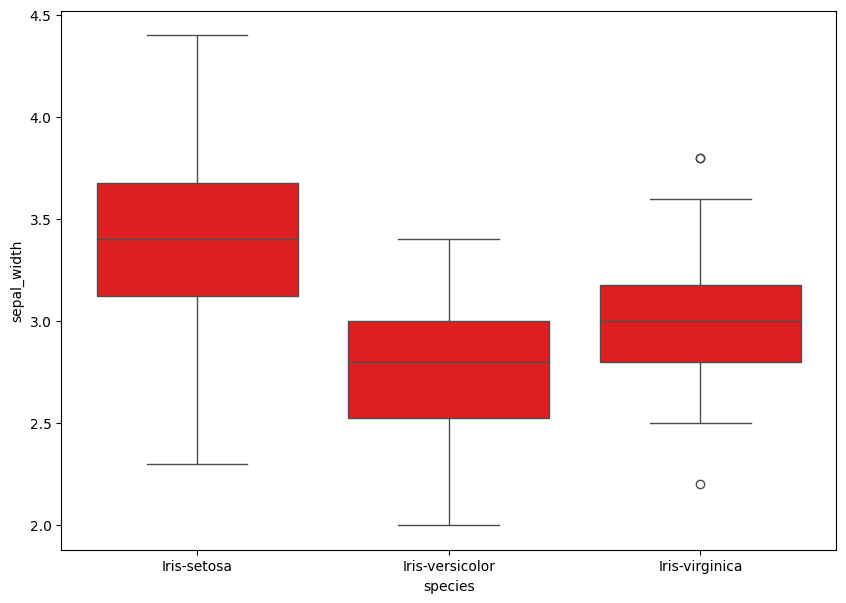

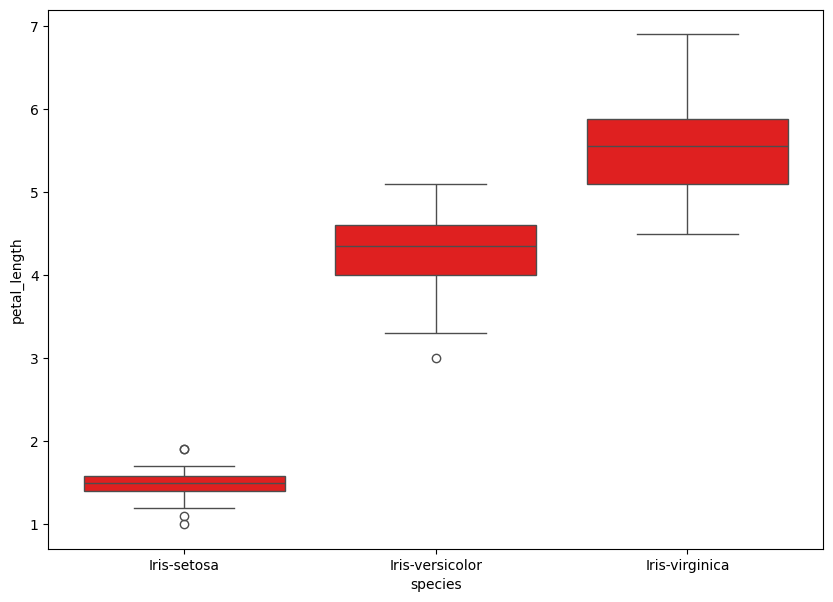

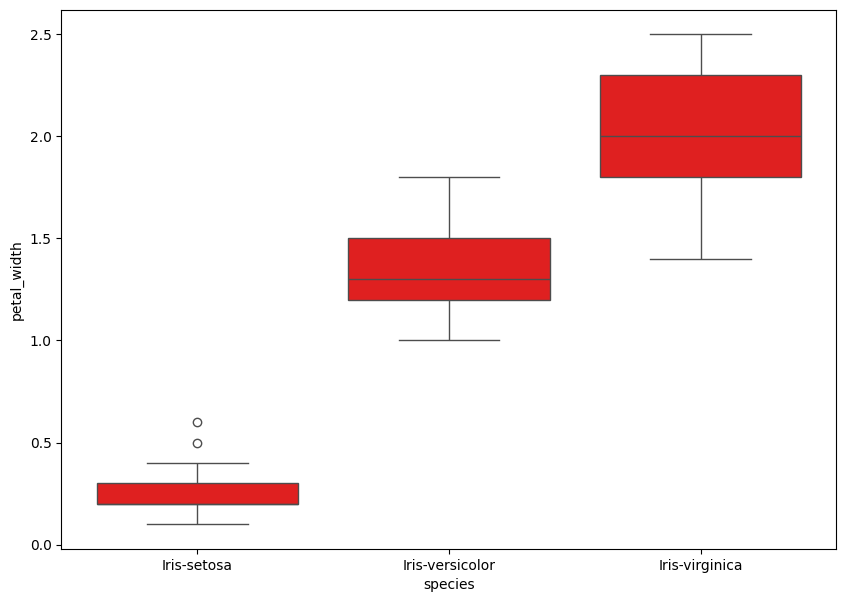

In [10]:
for i in cols:
    plt.figure(figsize=(10,7))
    sns.boxplot(data=df,x='species',y=i,color='red')
    plt.plot()

## Boxplot Insights

Sepal length and sepal width show noticeable overlap across species, limiting their standalone discriminative power. In contrast, petal length and petal width exhibit clear separation, with Iris-setosa having significantly smaller values, versicolor intermediate, and virginica the largest. Minimal overlap in petal features highlights them as the strongest predictors for species classification.

## Correlation heatmap

It basically shows what relationship exist among all features

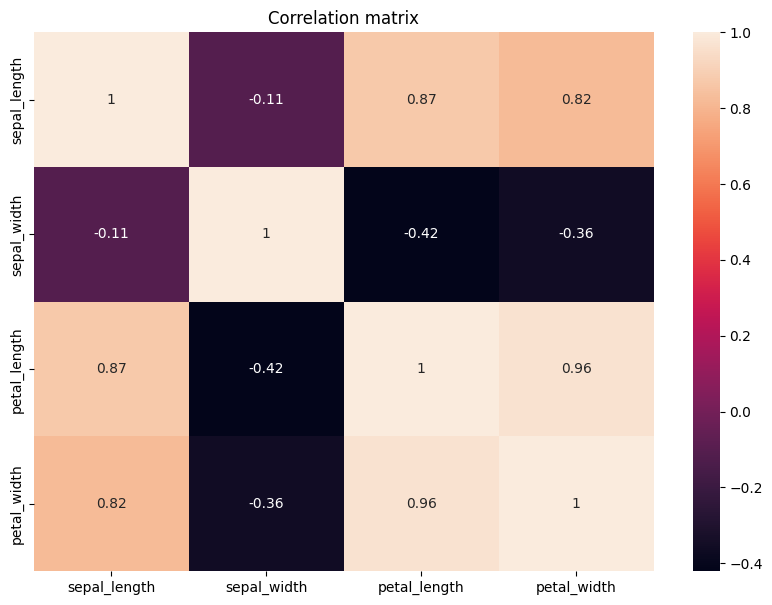

In [11]:
plt.figure(figsize=(10,7))
sns.heatmap(cols.corr(),annot=True)
plt.title('Correlation matrix')
plt.show()

## HeatMap observation

Petal length and petal width show a very strong positive correlation (0.96), making them highly informative and closely related features. Sepal length also correlates strongly with petal dimensions, while sepal width shows weak to moderate negative correlations, indicating limited predictive contribution. This suggests petal features dominate model performance, with potential multicollinearity between them.

# Data Preprocessing

In [12]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [13]:
encided_t=le.fit_transform(df['species'])

# Splitting data

In [14]:
X=df.drop('species',axis=1)
Y=encided_t

## Train-Test Split

In [15]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

# Model Training

In [16]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()

In [17]:
# fitting the model and making prediction on it
model=rf.fit(x_train,y_train)
pred=model.predict(x_test)

# Model Evaluation

In [18]:
from sklearn.metrics import accuracy_score, classification_report
acc=accuracy_score(pred,y_test)
report=classification_report(y_test,pred)
print(f"The accuracy of model :- {acc}")
print(f"The classifcation report :- \n {report}")

The accuracy of model :- 1.0
The classifcation report :- 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Model conclusion

The model achieves 100% accuracy, correctly classifying all test samples across all three classes. Precision, recall, and F1-score of 1.00 for each class indicate perfect class-wise prediction with no misclassifications. This suggests the model fits the Iris dataset extremely well, likely due to the strong separability of petal features.

# Cross-Validation

Cross-validation is a powerful technique in machine learning to evaluate a model's performance and prevent overfitting by systematically splitting data into training and testing subsets, training multiple models, and averaging their results, giving an unbiased estimate of how well the model generalizes to new, unseen data using

In [19]:
from sklearn.model_selection import cross_val_score
cvs=cross_val_score(model,X,Y,cv=10)
print(f"cross validation score is :- {cvs}")

cross validation score is :- [1.         0.93333333 1.         0.93333333 0.93333333 0.93333333
 0.86666667 1.         1.         1.        ]


In [20]:
# mean of avg of cross validation scores
cvs.mean() 

np.float64(0.96)

## Cross-Validation conclusion

Cross validation was done with 10-fold CV. The model showed consistently high accuracy across all folds, confirming that it generalizes well and is not overfitting to a single train–test split.

# Confusion Matrix

A confusion matrix in machine learning is a table comparing actual vs. predicted class labels

In [21]:
from sklearn.metrics import confusion_matrix
cf=confusion_matrix(y_test,pred)
cf

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

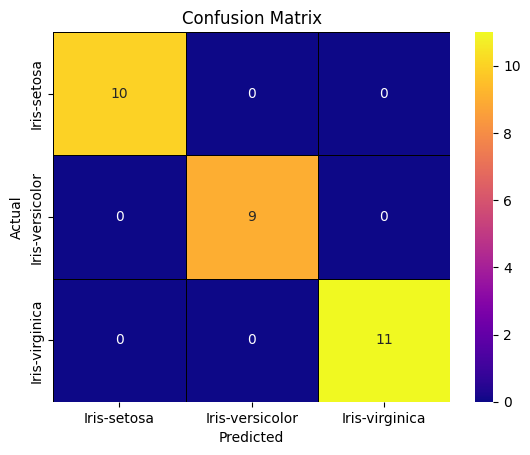

In [22]:
label=df['species'].unique()
sns.heatmap(data=cf,
            annot=True,
            cmap='plasma',
            linewidth='0.5',
            linecolor='black',
            xticklabels=label,
            yticklabels=label)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Conclusion

The Iris dataset analysis showed us that petal length and width are the most important features for identifying species. A simple classifier achieved perfect accuracy, correctly predicting all samples. Cross-validation confirmed that the model generalizes well, and the confusion matrix showed no misclassifications. Overall, the workflow demonstrates effective supervised classification on a clean, well-separated dataset. This was my attempt at the Iris Flower Dataset. I'm all ears for any suggestion you might have Thanks for getting this far :)